In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
import pandas as pd
df = pd.read_csv('laptopPrice.csv')
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [51]:
# clean object for to numeric 
cols_gb = ["ram_gb", "ssd", "hdd", "graphic_card_gb"]

for col in cols_gb:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(" GB", "", regex=False)
        .str.replace("GB", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# os_bit: '-bit' deleted
if "os_bit" in df.columns:
    df["os_bit"] = (
        df["os_bit"]
        .astype(str)
        .str.replace("-bit", "", regex=False)
        .str.strip()
    )
    df["os_bit"] = pd.to_numeric(df["os_bit"], errors="coerce").fillna(0).astype(int)

# rating: ' stars' deleted
if "rating" in df.columns:
    df["rating"] = (
        df["rating"]
        .astype(str)
        .str.replace(" stars", "", regex=False)
        .str.strip()
    )
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce").fillna(0).astype(int)

print(df[["ram_gb", "ssd", "hdd", "os_bit", "graphic_card_gb", "rating"]].dtypes)
df[["ram_gb", "ssd", "hdd", "os_bit", "graphic_card_gb", "rating"]].head()

ram_gb             int64
ssd                int64
hdd                int64
os_bit             int64
graphic_card_gb    int64
rating             int64
dtype: object


,ram_gb,ssd,hdd,os_bit,graphic_card_gb,rating
0,4,0,1024,64,0,2
1,4,0,1024,64,0,3
2,4,0,1024,64,0,3
3,8,512,0,32,2,3
4,4,0,512,64,0,3


In [52]:
# warranty values turn to numeric
warranty_map = {
    "No warranty": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3
}

df["warranty"] = df["warranty"].replace(warranty_map)
df["warranty"] = pd.to_numeric(df["warranty"], errors="coerce").fillna(0).astype(int)

print(df["warranty"].dtype)
print(df["warranty"].value_counts())

int64
warranty
1    509
0    278
2     23
3     13
Name: count, dtype: int64


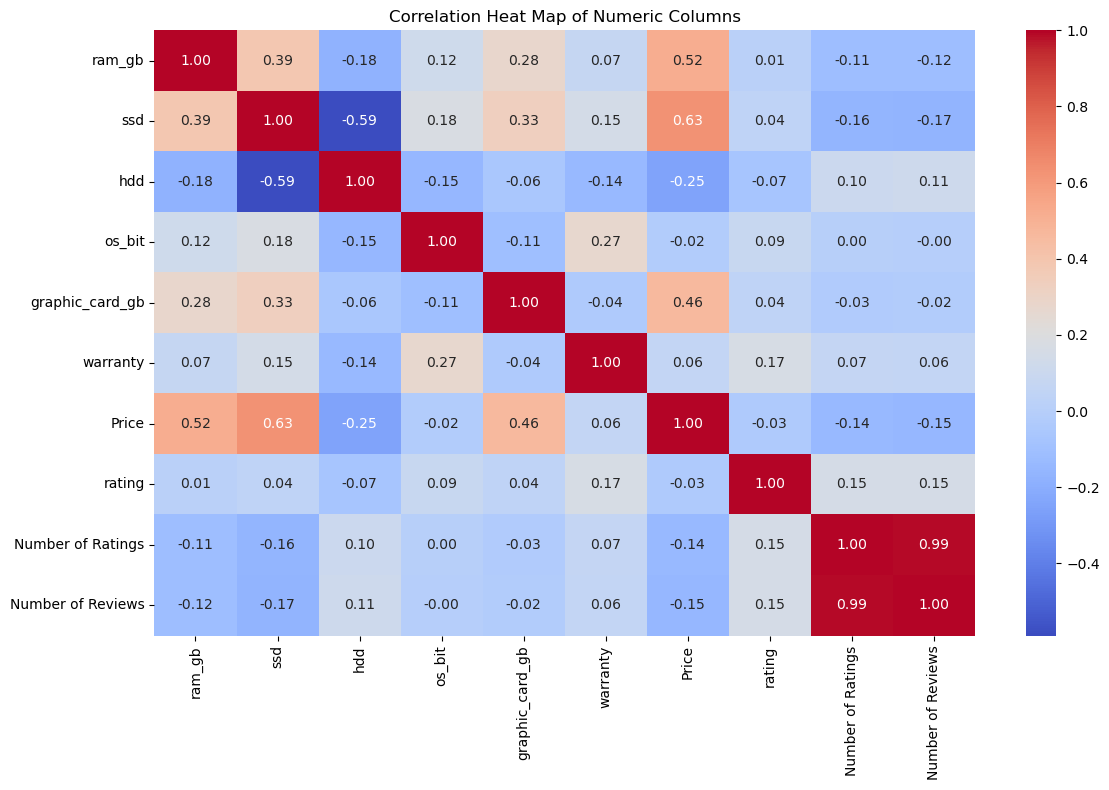

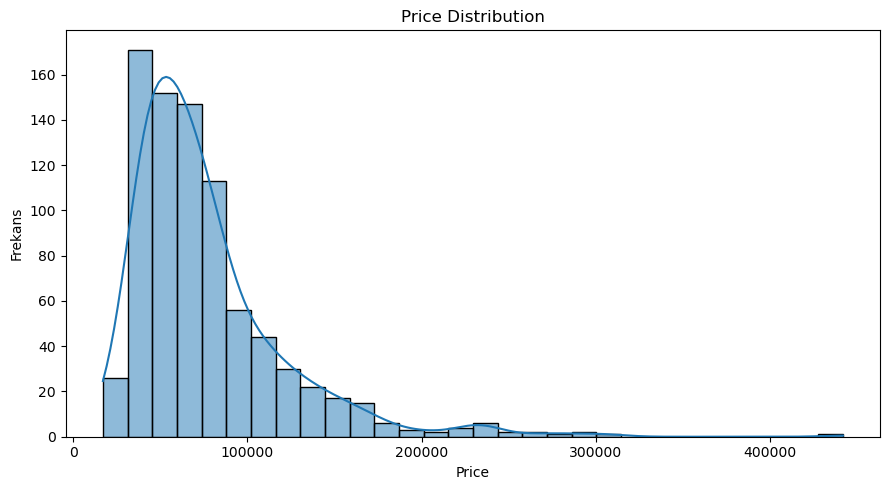

Price distortion (skewness): 2.389
The distribution appears skewed to the right.


In [53]:
# 1) Correlation heat map
num_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 8))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heat Map of Numeric Columns")
plt.tight_layout()
plt.show()

# 2) Price ditribution (histogram + kde)
plt.figure(figsize=(9, 5))
sns.histplot(df["Price"], kde=True, bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

# Saga distortion control
price_skew = df["Price"].skew()
print(f"Price distortion (skewness): {price_skew:.3f}")
if price_skew > 0.5:
    print("The distribution appears skewed to the right.")
elif price_skew < -0.5:
    print("The distribution appears skewed to the left.")
else:
    print("The distribution appears to be approximately symmetrical.")

In [54]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,No,No,34649,2,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,No,No,38999,3,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,No,No,39999,3,8,1
3,ASUS,Intel,Core i5,10th,8,DDR4,512,0,Windows,32,2,Casual,0,No,No,69990,3,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4,DDR4,0,512,Windows,64,0,Casual,0,No,No,26990,3,0,0


In [55]:
# One-Hot Encoding (drop_first=True)
cat_cols = ['brand', 'processor_brand', 'processor_name', 'ram_type', 'os']
existing_cat_cols = [c for c in cat_cols if c in df.columns]

df_final = pd.get_dummies(df, columns=existing_cat_cols, drop_first=True)

df_final.head()

,processor_gnrtn,ram_gb,ssd,hdd,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,...,processor_name_Ryzen 5,processor_name_Ryzen 7,processor_name_Ryzen 9,ram_type_DDR4,ram_type_DDR5,ram_type_LPDDR3,ram_type_LPDDR4,ram_type_LPDDR4X,os_Mac,os_Windows
0,10th,4,0,1024,64,0,Casual,0,No,No,...,False,False,False,True,False,False,False,False,False,True
1,10th,4,0,1024,64,0,Casual,0,No,No,...,False,False,False,True,False,False,False,False,False,True
2,10th,4,0,1024,64,0,Casual,0,No,No,...,False,False,False,True,False,False,False,False,False,True
3,10th,8,512,0,32,2,Casual,0,No,No,...,False,False,False,True,False,False,False,False,False,True
4,Not Available,4,0,512,64,0,Casual,0,No,No,...,False,False,False,True,False,False,False,False,False,True


In [56]:
# One-Hot Encoding (0/1 integer)
cat_cols = ['brand', 'processor_brand', 'processor_name', 'ram_type', 'os']
existing_cat_cols = [c for c in cat_cols if c in df.columns]

df_final = pd.get_dummies(df, columns=existing_cat_cols, drop_first=True, dtype=int)

df_final.head()

,processor_gnrtn,ram_gb,ssd,hdd,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,...,processor_name_Ryzen 5,processor_name_Ryzen 7,processor_name_Ryzen 9,ram_type_DDR4,ram_type_DDR5,ram_type_LPDDR3,ram_type_LPDDR4,ram_type_LPDDR4X,os_Mac,os_Windows
0,10th,4,0,1024,64,0,Casual,0,No,No,...,0,0,0,1,0,0,0,0,0,1
1,10th,4,0,1024,64,0,Casual,0,No,No,...,0,0,0,1,0,0,0,0,0,1
2,10th,4,0,1024,64,0,Casual,0,No,No,...,0,0,0,1,0,0,0,0,0,1
3,10th,8,512,0,32,2,Casual,0,No,No,...,0,0,0,1,0,0,0,0,0,1
4,Not Available,4,0,512,64,0,Casual,0,No,No,...,0,0,0,1,0,0,0,0,0,1


In [57]:
# Correct the final text and create the final table
work_df = df.copy()

# Yes/No -> 1/0 
yn_map = {'Yes': 1, 'No': 0}
for col in ['Touchscreen', 'msoffice']:
    if col in work_df.columns:
        work_df[col] = work_df[col].replace(yn_map)
        work_df[col] = pd.to_numeric(work_df[col], errors='coerce').fillna(0).astype(int)

# processor_gnrtn and weight icin One-Hot Encoding (0/1 int)
ohe_cols = [c for c in ['processor_gnrtn', 'weight'] if c in work_df.columns]

# If `df_final` has already been created, continue using it; otherwise, use `work_df`
base_df = df_final.copy() if 'df_final' in globals() else work_df.copy()

# Ensure that the Yes/No conversion in `base_df` is performed again
for col in ['Touchscreen', 'msoffice']:
    if col in base_df.columns:
        base_df[col] = base_df[col].replace(yn_map)
        base_df[col] = pd.to_numeric(base_df[col], errors='coerce').fillna(0).astype(int)

# Apply One-Hot Encoding to the existing `base_df`
cols_to_encode = [c for c in ohe_cols if c in base_df.columns]
df_final = pd.get_dummies(base_df, columns=cols_to_encode, drop_first=True, dtype=int)

# Control
print(df_final[['Touchscreen', 'msoffice']].dtypes if set(['Touchscreen','msoffice']).issubset(df_final.columns) else 'Touchscreen/msoffice kolonlari bulunamadi')
print('df_final shape:', df_final.shape)
df_final.head()

Touchscreen    int64
msoffice       int64
dtype: object
df_final shape: (823, 47)


C:\Users\CG\AppData\Local\Temp\ipykernel_24264\3785684364.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work_df[col] = work_df[col].replace(yn_map)
C:\Users\CG\AppData\Local\Temp\ipykernel_24264\3785684364.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work_df[col] = work_df[col].replace(yn_map)
C:\Users\CG\AppData\Local\Temp\ipykernel_24264\3785684364.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_o

,ram_gb,ssd,hdd,os_bit,graphic_card_gb,warranty,Touchscreen,msoffice,Price,rating,...,os_Windows,processor_gnrtn_11th,processor_gnrtn_12th,processor_gnrtn_4th,processor_gnrtn_7th,processor_gnrtn_8th,processor_gnrtn_9th,processor_gnrtn_Not Available,weight_Gaming,weight_ThinNlight
0,4,0,1024,64,0,0,0,0,34649,2,...,1,0,0,0,0,0,0,0,0,0
1,4,0,1024,64,0,0,0,0,38999,3,...,1,0,0,0,0,0,0,0,0,0
2,4,0,1024,64,0,0,0,0,39999,3,...,1,0,0,0,0,0,0,0,0,0
3,8,512,0,32,2,0,0,0,69990,3,...,1,0,0,0,0,0,0,0,0,0
4,4,0,512,64,0,0,0,0,26990,3,...,1,0,0,0,0,0,0,1,0,0


In [58]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 47 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   ram_gb                         823 non-null    int64
 1   ssd                            823 non-null    int64
 2   hdd                            823 non-null    int64
 3   os_bit                         823 non-null    int64
 4   graphic_card_gb                823 non-null    int64
 5   warranty                       823 non-null    int64
 6   Touchscreen                    823 non-null    int64
 7   msoffice                       823 non-null    int64
 8   Price                          823 non-null    int64
 9   rating                         823 non-null    int64
 10  Number of Ratings              823 non-null    int64
 11  Number of Reviews              823 non-null    int64
 12  brand_ASUS                     823 non-null    int64
 13  brand_Avita         

In [59]:
# Price Prediction: Random Forest Regressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# conquer target and features
y = df_final['Price']
X = df_final.drop(columns=['Price'])

# Train/Test  (%80/%20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Create and train model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and metrics
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R2 Score: 0.7367
Mean Absolute Error (MAE): 12699.1897


In [60]:
# Remove outliers (delete those where Price > 200,000) and retrain the model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

before_rows = len(df_final)
df_filtered = df_final[df_final['Price'] <= 200000].copy()
after_rows = len(df_filtered)
deleted_rows = before_rows - after_rows

# X / y conquer
X = df_filtered.drop(columns=['Price'])
y = df_filtered['Price']

# Train/Test divide (%80/%20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train model Random Forest
rf_model_filtered = RandomForestRegressor(random_state=42)
rf_model_filtered.fit(X_train, y_train)

# Predict and metrics
y_pred = rf_model_filtered.predict(X_test)
r2_new = r2_score(y_test, y_pred)
mae_new = mean_absolute_error(y_test, y_pred)

print(f"Number of deleted rows: {deleted_rows}")
print(f"Number of remaining lines: {after_rows}")
print(f"New R2 Score: {r2_new:.4f}")
print(f"New MAE: {mae_new:.4f}")

Number of deleted rows: 21
Number of remaining lines: 802
New R2 Score: 0.7688
New MAE: 10037.8411


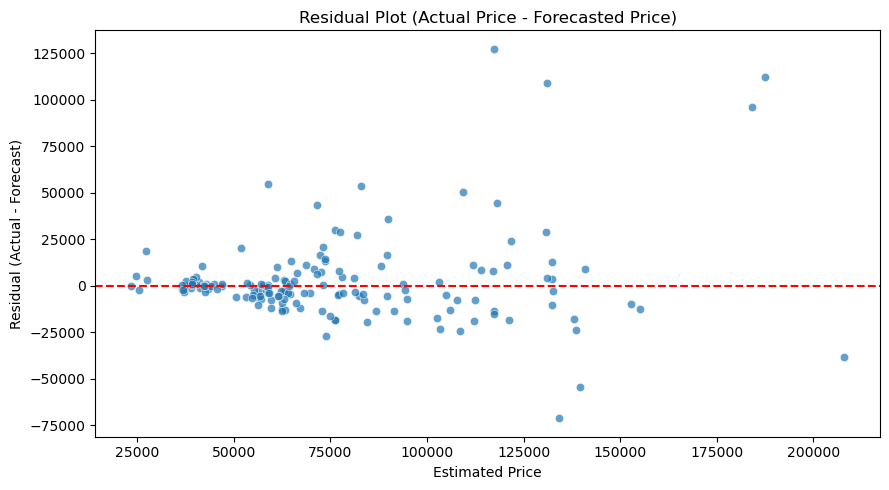

Average absolute error by price range (MAE):
price_range
(22989.999, 44306.0]     1604.507403
(44306.0, 57296.0]       7300.314388
(57296.0, 75994.0]       8184.421918
(75994.0, 104190.0]     12520.783044
(104190.0, 299990.0]    32583.508835
Name: abs_error, dtype: float64


C:\Users\CG\AppData\Local\Temp\ipykernel_24264\1117591583.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_mae = error_df.groupby('price_range')['abs_error'].mean().sort_index()


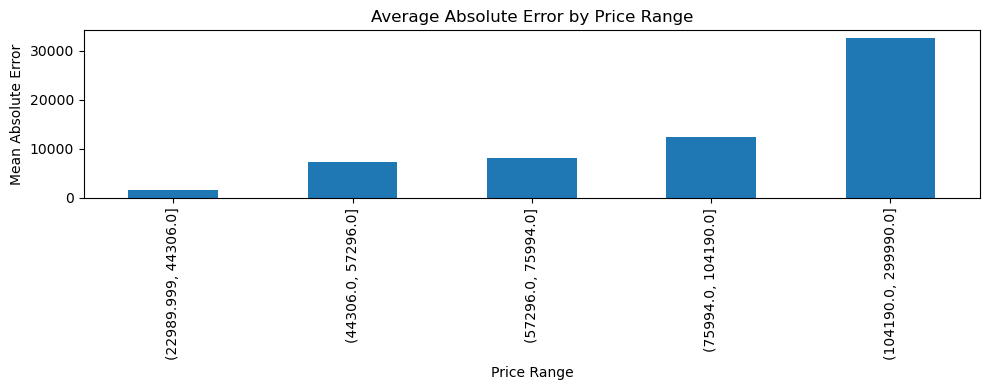


The price range where the most mistakes are made:
(104190.0, 299990.0] -> MAE: 32583.51


In [61]:
# Residual Plot (Gercek - Tahmin) ve fiyat araligina gore hata analizi
# Not: Bir onceki hucrede olusan y_test_real ve y_pred_real degiskenlerini kullanir.

residuals = y_test_real - y_pred_real

plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_pred_real, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot (Actual Price - Forecasted Price)')
plt.xlabel('Estimated Price')
plt.ylabel('Residual (Actual - Forecast)')
plt.tight_layout()
plt.show()

# Examine the error density by price range
error_df = pd.DataFrame({
    'actual_price': y_test_real,
    'pred_price': y_pred_real
})
error_df['abs_error'] = (error_df['actual_price'] - error_df['pred_price']).abs()

# Divide into 5 equal groups (based on quantiles)
error_df['price_range'] = pd.qcut(error_df['actual_price'], q=5, duplicates='drop')
range_mae = error_df.groupby('price_range')['abs_error'].mean().sort_index()

print('Average absolute error by price range (MAE):')
print(range_mae)

plt.figure(figsize=(10, 4))
range_mae.plot(kind='bar')
plt.title('Average Absolute Error by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Mean Absolute Error')
plt.tight_layout()
plt.show()

print('\nThe price range where the most mistakes are made:')
print(range_mae.idxmax(), '->', f"MAE: {range_mae.max():.2f}")

In [62]:
# Hyperparameter optimization for Random Forest using RandomizedSearchCV
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Features and specifications (based on actual price)
X = df_final.drop(columns=['Price'])
y = df_final['Price']

# %80-%20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Baseline model 
baseline_rf = RandomForestRegressor(random_state=42)
baseline_rf.fit(X_train, y_train)
baseline_pred = baseline_rf.predict(X_test)
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

# Parameter search space
param_distributions = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Search for the best parameters
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print('Best Params:', random_search.best_params_)

# Test metrics using the best model
best_pred = best_rf.predict(X_test)
best_r2 = r2_score(y_test, best_pred)
best_mae = mean_absolute_error(y_test, best_pred)

print(f"\nBaseline R2: {baseline_r2:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Tuned R2: {best_r2:.4f}")
print(f"Tuned MAE: {best_mae:.4f}")

print('\nComparison:')
print(f"R2 difference  (Tuned - Baseline): {best_r2 - baseline_r2:.4f}")
print(f"MAE difference  (Baseline - Tuned): {baseline_mae - best_mae:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

Baseline R2: 0.7367
Baseline MAE: 12699.1897
Tuned R2: 0.7306
Tuned MAE: 12999.5740

Comparison:
R2 difference  (Tuned - Baseline): -0.0061
MAE difference  (Baseline - Tuned): -300.3842


In [64]:
# Final step: Remove outliers and rebuild the model using the best parameters
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1) Exclude values where the price is greater than or equal to 125,000
df_boost = df_final[df_final['Price'] < 125000].copy()

# 2) X / y ayir
X = df_boost.drop(columns=['Price'])
y = df_boost['Price']

# 3) Train/Test split (%80/%20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 4) Best Params'i use
if 'random_search' in globals() and hasattr(random_search, 'best_params_'):
    best_params = random_search.best_params_
else:
    # If the tuning cell did not work, use the safe default
    best_params = {
        'n_estimators': 300,
        'max_depth': None,
        'min_samples_split': 2,
        'min_samples_leaf': 1
    }

rf_best_filtered = RandomForestRegressor(
    random_state=42,
    **best_params
)
rf_best_filtered.fit(X_train, y_train)

# 5) Test metrics
y_pred = rf_best_filtered.predict(X_test)
r2_new = r2_score(y_test, y_pred)
mae_new = mean_absolute_error(y_test, y_pred)

print('Best parameters used:', best_params)
print(f"Number of rows processed: {len(df_boost)}")
print(f"New R2 Score: {r2_new:.4f}")
print(f"New MAE: {mae_new:.4f}")

Best parameters used: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
Number of rows processed: 729
New R2 Score: 0.8239
New MAE: 6587.7986


In [65]:
# A simple function for estimating the price of a new laptop
import pandas as pd

# Select the model to use (use “best_rf” if available)
if 'best_rf' in globals():
    model_for_predict = best_rf
elif 'rf_best_filtered' in globals():
    model_for_predict = rf_best_filtered
else:
    raise ValueError("No model trained for prediction was found. Please run the tuning/model cells first.")


def tahmin_fiyat(
    brand,
    processor_brand,
    processor_name,
    ram_gb,
    ssd,
    graphic_card_gb=0,
    hdd=0,
    os_bit=64,
    rating=3,
    touchscreen=0,
    msoffice=0,
    warranty=1,
    num_ratings=0,
    num_reviews=0,
    ram_type='DDR4',
    os='Windows',
    processor_gnrtn='10th',
    weight='Casual'
):
    feature_cols = model_for_predict.feature_names_in_
    x_new = pd.DataFrame(0, index=[0], columns=feature_cols)

    # Numerical fields
    numeric_map = {
        'ram_gb': ram_gb,
        'ssd': ssd,
        'hdd': hdd,
        'os_bit': os_bit,
        'graphic_card_gb': graphic_card_gb,
        'rating': rating,
        'Touchscreen': touchscreen,
        'msoffice': msoffice,
        'warranty': warranty,
        'Number of Ratings': num_ratings,
        'Number of Reviews': num_reviews
    }
    for col, val in numeric_map.items():
        if col in x_new.columns:
            x_new.at[0, col] = val

    # One-hot
    ohe_targets = {
        f'brand_{brand}': 1,
        f'processor_brand_{processor_brand}': 1,
        f'processor_name_{processor_name}': 1,
        f'ram_type_{ram_type}': 1,
        f'os_{os}': 1,
        f'processor_gnrtn_{processor_gnrtn}': 1,
        f'weight_{weight}': 1,
    }
    for col, val in ohe_targets.items():
        if col in x_new.columns:
            x_new.at[0, col] = val

    pred_price = model_for_predict.predict(x_new)[0]
    return f"Estimated Price: {pred_price:,.2f} TL"


# Example Prediction: ASUS, Intel Core i5, 8GB RAM, 512GB SSD
print(
    tahmin_fiyat(
        brand='ASUS',
        processor_brand='Intel',
        processor_name='Core i5',
        ram_gb=8,
        ssd=512,
        graphic_card_gb=2,
        hdd=0,
        os='Windows',
        ram_type='DDR4',
        processor_gnrtn='10th',
        weight='Casual'
    )
)

Estimated Price: 75,859.78 TL
